## 3G2 Python Code

### Import Packages

In [131]:
import numpy as np # allows the use of arrays, and provides many useful functions
import matplotlib.pyplot as plt # plotting functionality
from scipy import integrate # numerical integration tool for ode's

### Physiological Parameters

In [132]:
p = dict(Pl=0, M=0.45, K=250000, B=100, x01=0.1, dx0=0.01, tau=0.002)

### ODE Definition
Define the function $f$ on the right hand side of,
$$
\frac{d\mathbf{x}}{d t} = f(\mathbf x,t,p),
$$
where $\mathbf x$ is the vector of state variables, $t$ is time, and $p$ is a set of parameters that define $f$.

In [133]:
def f(x, t, p):

    x1, x2 = x   # x1 = epsilon, x2 = epsilon_dot

    # first equation
    dx1 = x2

    # aerodynamic pressure term
    pressure = p['Pl'] * (p['dx0'] + 2*p['tau']*x2) / (p['x01'] + x1 + p['tau']*x2)

    # second equation
    dx2 = (pressure - p['B']*x2 - p['K']*x1) / p['M']

    return [dx1, dx2]

### Solving Function
Create a function that will solve the equation $d\mathbf x/dt = f(\mathbf x,t,p)$ over the time interval $[0,T]$ given the initial condition $\mathbf x_0$ and the parameters $p$.

In [134]:
def run_oscil(x0,T,p):
    t = np.linspace(0, T, 1000)
    dxdt = lambda x,t : f(x, t, p)
    x_t = integrate.odeint(dxdt, x0, t)
    return(t,x_t)

Use this function to solve for $\mathbf x(t)$ given $\mathbf x_0$, $T$, and $p$.

/tmp/ipykernel_8882/3177927505.py:4: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  x_t = integrate.odeint(dxdt, x0, t)


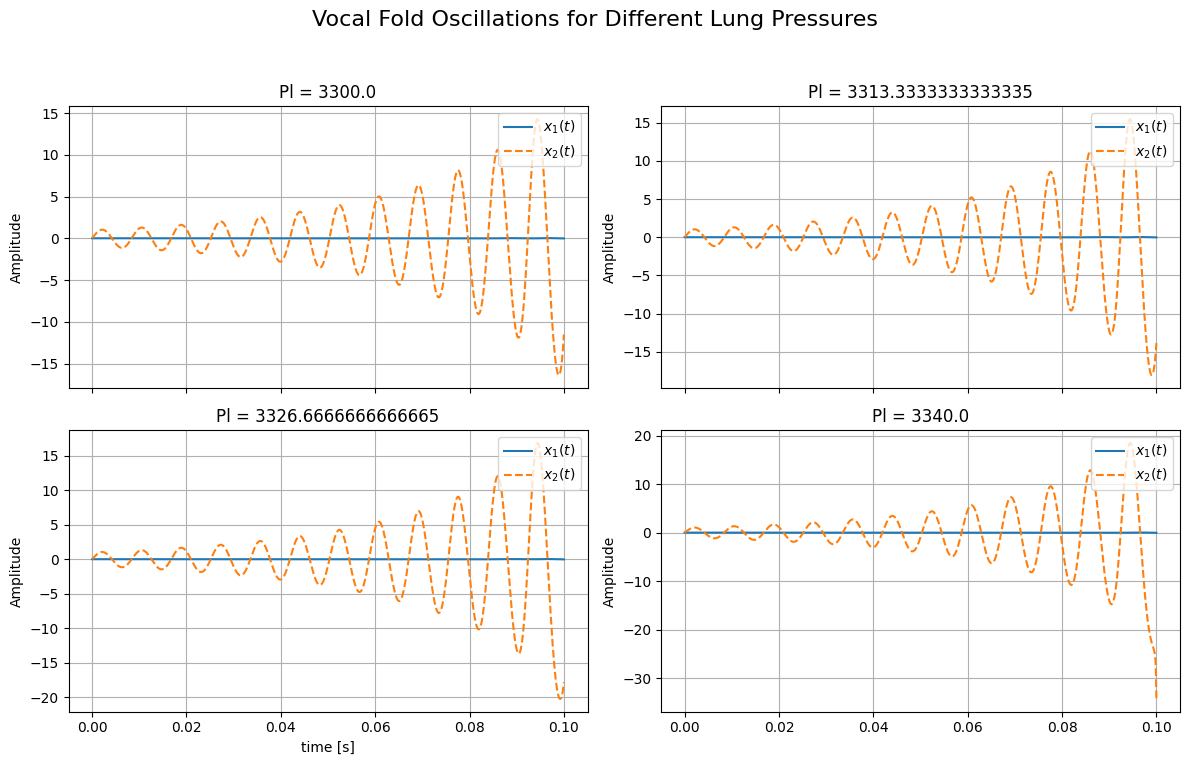

In [141]:
def plot_individual_pressure_plots(p_values, x0, T, p):
    num_pressures = len(p_values)
    # Calculate rows and columns for a 3x2 layout for 6 plots
    rows = (num_pressures + 1) // 2 # Ensures enough rows, handles odd number of plots by adding one more row for the single plot
    cols = 2

    # Adjust figsize for a 3x2 layout
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True)
    fig.suptitle('Vocal Fold Oscillations for Different Lung Pressures', fontsize=16)

    # Flatten axes array for easier iteration if num_pressures > 1
    # or handle the case where subplots returns a single Axes object
    if num_pressures == 1:
        axes = np.array([[axes]]) # Make it 2D for consistent indexing
    elif num_pressures > 1 and num_pressures % 2 != 0: # If odd number of plots, remove the last empty subplot
        # axes is already 2D, but we might have an unused subplot in the last row
        axes_flat = axes.flatten()
        for j in range(num_pressures, rows * cols):
            fig.delaxes(axes_flat[j]) # Delete empty subplots


    original_Pl = p['Pl'] # Store the original Pl value

    for i, Pl_val in enumerate(p_values):
        row = i // cols
        col = i % cols
        current_ax = axes[row, col]

        p['Pl'] = Pl_val
        t, x_t = run_oscil(x0, T, p)

        current_ax.plot(t, x_t[:, 0], label=f'$x_1(t)$')
        current_ax.plot(t, x_t[:, 1], label=f'$x_2(t)$', linestyle='--')
        current_ax.set_ylabel('Amplitude')
        current_ax.set_title(f'Pl = {Pl_val}')
        current_ax.legend(loc='upper right')
        current_ax.grid(True)

    # Set xlabel only on the bottom row plots that are used
    for col_idx in range(cols):
        if rows * col_idx + (rows-1)*cols < num_pressures: # Check if there is a plot in the last row, current column
            axes[rows-1, col_idx].set_xlabel('time [s]')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    p['Pl'] = original_Pl # Restore original Pl value after plotting

# Define the pressures, initial condition, and time period
pressures = np.linspace(3300,3340,4)
x0 = [1e-6, 0.0]
T = 0.1

# Call the function to generate the subplots
plot_individual_pressure_plots(pressures, x0, T, p)

In [147]:
def plot_phase_portraits(p_values, x0, T, p):

    import numpy as np
    import matplotlib.pyplot as plt

    num_pressures = len(p_values)
    rows = (num_pressures + 1)//2
    cols = 2

    fig, axes = plt.subplots(rows, cols, figsize=(12,5*rows))
    axes = np.atleast_2d(axes)


    original_Pl = p['Pl']

    # singularity line
    eps_line = np.linspace(-0.1,0.1,400)
    epsdot_line = -(p['x01'] + eps_line)/p['tau']

    for i, Pl in enumerate(p_values):

        r = i//cols
        c = i%cols
        ax = axes[r,c]

        p_local = p.copy()
        p_local['Pl'] = Pl

        t, x_t = run_oscil(x0, T, p_local)

        eps = x_t[:,0]
        eps_dot = x_t[:,1]


        ax.plot(eps, eps_dot, lw=1.5)

        # closure line
        ax.plot(eps_line, epsdot_line,'r--',label="closure line")

        ax.set_xlabel(r'$\epsilon$')
        ax.set_ylabel(r'$\dot{\epsilon}$')
        ax.set_title(f"Pl = {Pl}")
        ax.grid(True)


    ax.set_xlim(-0.04, 0.04)
    ax.set_ylim(-60, 30)

    plt.tight_layout()
    plt.show()

    p['Pl'] = original_Pl

/tmp/ipykernel_8882/3177927505.py:4: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  x_t = integrate.odeint(dxdt, x0, t)


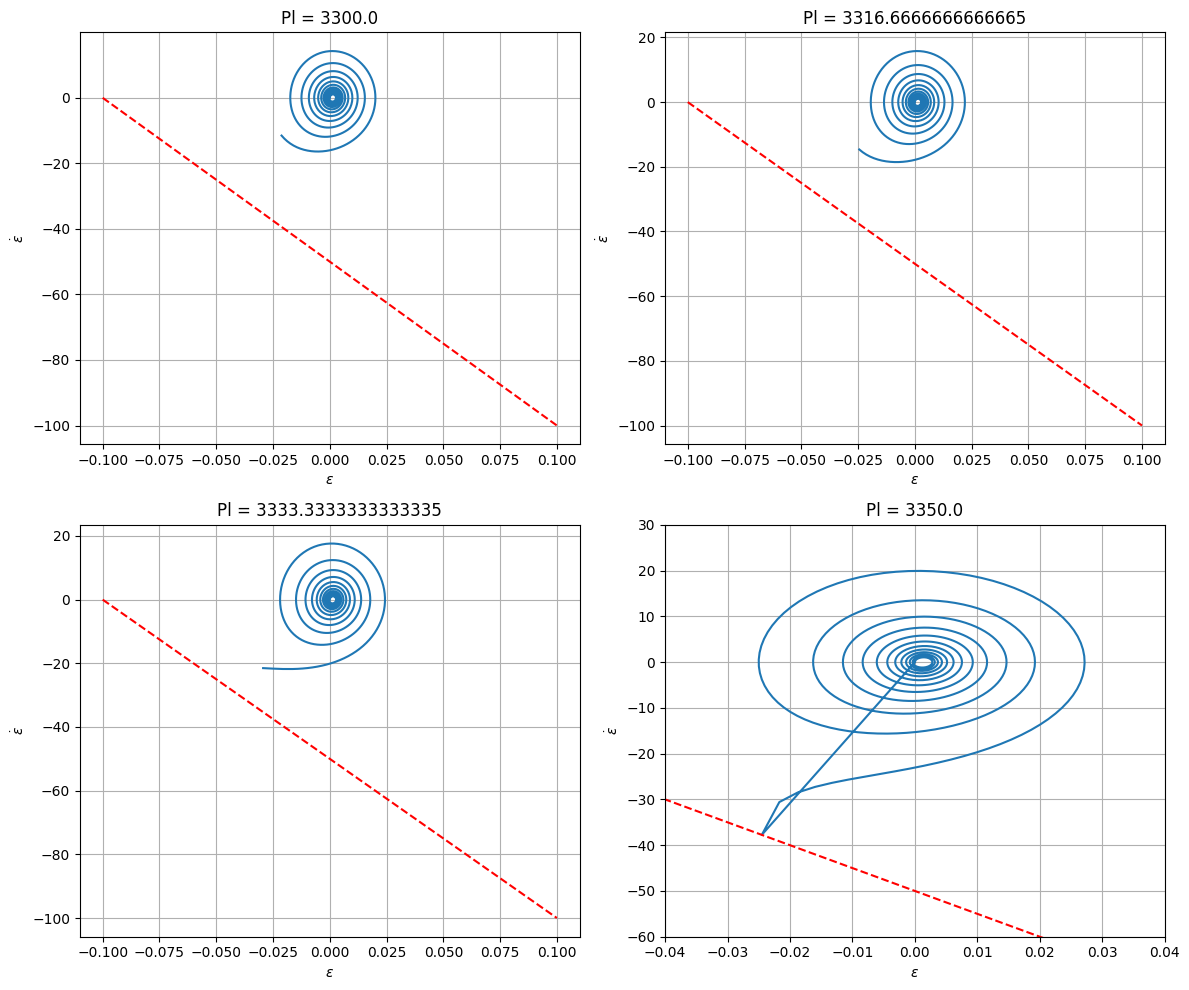

In [150]:
pressures = np.linspace(3300,3350,4)

x0 = [1e-6,0]
T = 0.1

plot_phase_portraits(pressures, x0, T, p)